In [3]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf

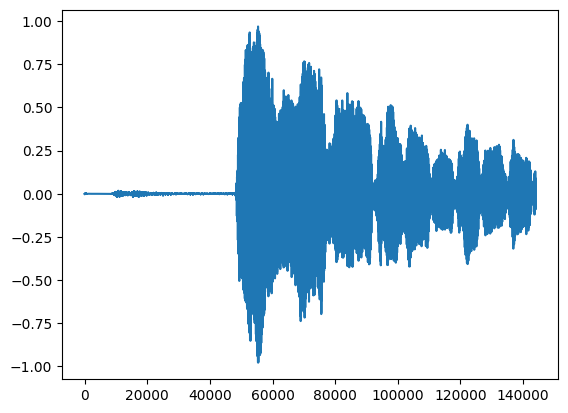

In [ ]:
# # fs = 44100  # Sample rate given in sounddevice example 
# fs = 48e3
# seconds = 3  # Duration of recording

# myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
# sd.wait()  # Wait until recording is finished
# plt.plot(myrecording)

In [7]:
hello, fs = sf.read('hello.wav', dtype='float32')
# plt.plot(myrecording)

In [122]:
fs

48000

Human voice frequencies: human vocal range 

Total bandwidth: 50Hz-7kHz. Split equally in three to start. 
Procedure is to filter the microphone input (voice) and filter the sawtooth (pitch) with B1. Then mix the results. Repeat the same for B2 and B3. Add all the mixed signals together to produce the output
The sawtooth is produced by 

In [105]:
band2, band1, band3

(683.3333333333334, 366.6666666666667, 1000.0)

In [123]:
# Choose bandwidth ranges 
fmin = 50
fmax = 1e3
segment = (fmax-fmin)/3 # divide bandwidth equally into three segments 
band1 = fmin + segment
band2 = band1 + segment
band3 = band2 + segment

# Choose number of filter taps 
Ntaps = 1200

# Extract FIR bandpass filter coefficients for each bandwidth
fir_b1 = np.array(sig.firwin(Ntaps, cutoff=[fmin, band1], pass_zero='bandpass', fs=fs)) # cutoff should correspond with -6dB 
fir_b2 = np.array(sig.firwin(Ntaps, cutoff=[band1, band2], pass_zero='bandpass', fs=fs)) 
fir_b3 = np.array(sig.firwin(Ntaps, cutoff=[band2, band3], pass_zero='bandpass', fs=fs)) 
# plt.stem(fir_b1)
# plt.stem(fir_b2)
# plt.stem(fir_b3)

<StemContainer object of 3 artists>

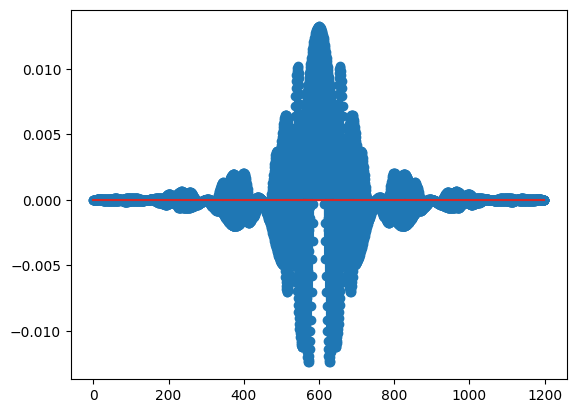

In [124]:
plt.stem(fir_b1)
plt.stem(fir_b2)
plt.stem(fir_b3)

In [133]:
x = hello
# Calculate filtering action using lfilter function 
mic_fir_1 = sig.lfilter(fir_b1, a=[1], x=x)
mic_fir_2 = sig.lfilter(fir_b2, a=[1], x=x)
mic_fir_3 = sig.lfilter(fir_b3, a=[1], x=x)

# Calculate filtering action by convolution 
mic_conv_1 = np.convolve(x, fir_b1)
mi_conv_2 = np.convolve(x, fir_b2)
mic_conv_3 = np.convolve(x, fir_b3)


# Generate sawtooth 
saw_periods = 500
samples = len(x)
n = np.linspace(0, saw_periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Calculate filtering action using lfilter function 
pitch_fir_1 = sig.lfilter(fir_b1, a=[1], x=pitch)
pitch_fir_2 = sig.lfilter(fir_b2, a=[1], x=pitch)
pitch_fir_3 = sig.lfilter(fir_b3, a=[1], x=pitch)

# # Calculate filtering action by convolution 
# pitch_conv_1 = np.convolve(pitch, fir_b1)
# pitch_conv_2 = np.convolve(pitch, fir_b2)
# pitch_conv_3 = np.convolve(pitch, fir_b3)

# fig, ax = plt.subplots(1,3, figsize=(20, 8))
# ax[0].stem(n, pitch)
# ax[0].set_ylim([-6, 6])
# ax[0].set_title('Input')

# ax[1].stem(pitch_conv_3)
# ax[1].set_title('Convolution')
# ax[1].set_ylim([-6, 6])

# ax[2].stem(pitch_fir_1)
# ax[2].set_ylim([-6, 6])
# ax[2].set_title('lfilter')

# out_myfilter = np.array([(mic_fir_1[i]*pitch_fir_1[i] + mic_fir_2[i]*pitch_fir_2[i] + mic_fir_3[i]*pitch_fir_3[i]) for i in range(len(mic_fir_1))])

out_myfilter = np.array([(mic_fir_3[i]*pitch_fir_3[i]) for i in range(len(mic_fir_1))])

In [134]:
sd.play(1e3*out_myfilter, fs)

In [79]:
sd.play(pitch, fs)

* compare 31 tap with 3 tap, IIR vs FIR 

* choose cutoff frequency, define lowpass filter as stepwise function on domain -pi to pi 
* build bandpass as a combination of low pass filters 
* the inverse transform will be some combination of shifted sinc functions. 
* window it to get an FIR filter but consider the trade offs: linear phase vs a lot of memory (nonlinear distortion) -> should we go for a lot of memory 
* choose a filter type (FIR filter) -> probably type 1 filter (from the tutorial, general can be any) OR we may have to do IIR (feedback makes it highly linear but stability issues)
* go to the LCCDE 
* for fun draw the block diagram 
* choose the number of taps in the fiter 

In [ ]:
fs = 200e3
f0 = 10e3
A = 5
phi = 10

n = np.arange(0, 100)

x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

b = [1, 0.5]
a = [1, 0.6]


y1 = sig.lfilter(b, a, x)

w, Hw =  sig.freqz(b, a)

# w is in rad/sample; one radian is pi

# y2 = abs(Hw)*A*np.cos(2*np.pi*(f0/fs)*n+phi + np.arg(Hw))



What does it mean that the thing is in radians per sample? 

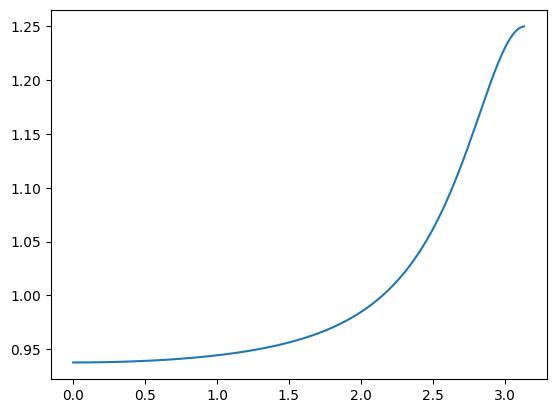

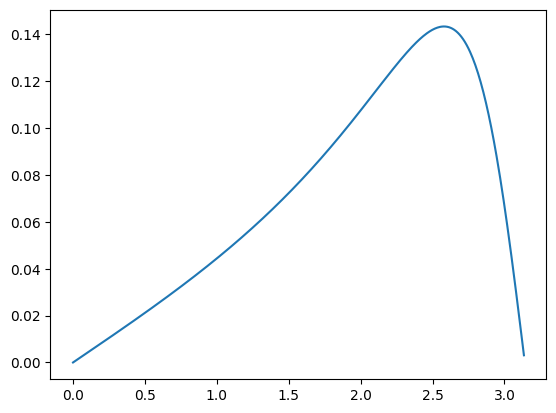

In [27]:
plt.plot(w, abs(Hw))
plt.figure()
plt.plot(w, np.angle(Hw))

<StemContainer object of 3 artists>

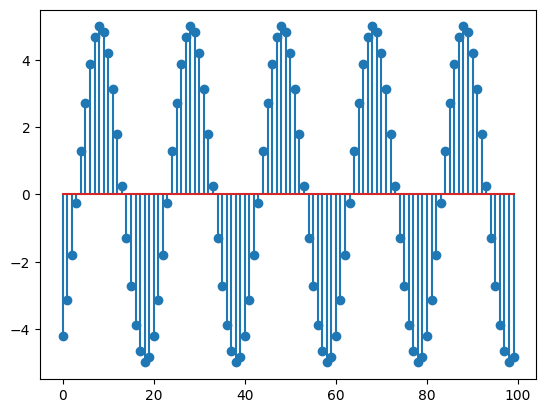

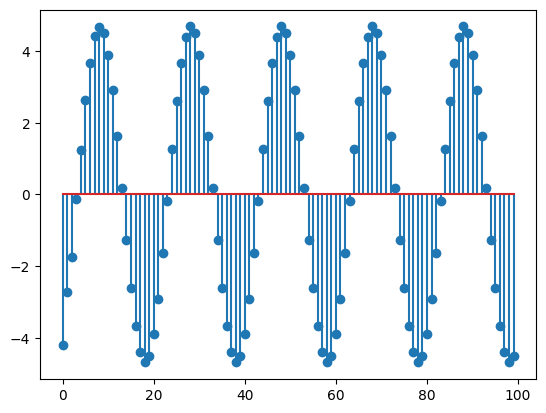

In [25]:
plt.stem(n, x)
plt.figure()
plt.stem(n, y1)

In [9]:
f0/fs

9.765625